In [1]:
import os
import glob
import pandas as pd
import re

# ===============================
# 폴더 경로
# ===============================
folder_path = "/home/ftk3187/github/IEMS490/model-based-diffusion_pytorch_tide/results/csv"
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

summary_rows = []

for file in csv_files:
    df = pd.read_csv(file)
    name = os.path.basename(file)

    # -----------------------------
    # lambda 값 추출 (소수점 포함)
    # -----------------------------
    lambda_match = re.search(r"lambda([\d\.]+)", name)
    lambda_val = float(lambda_match.group(1)) if lambda_match else None

    # -----------------------------
    # Ndiffuse 추출 (없으면 50)
    # -----------------------------
    ndiff_match = re.search(r"Ndiffuse_(\d+)", name)
    Ndiffuse_val = int(ndiff_match.group(1)) if ndiff_match else 50

    # -----------------------------
    # Nsample 추출 (없으면 2048)
    # -----------------------------
    nsample_match = re.search(r"Nsample_(\d+)", name)
    Nsample_val = int(nsample_match.group(1)) if nsample_match else 2048

    # -----------------------------
    # 시간 추출
    # -----------------------------
    total_time = df["elapsed_total_sec"].iloc[0]
    step_time = df["elapsed_per_step_sec"].iloc[0]

    summary_rows.append({
        "file": name,
        "lambda": lambda_val,
        "Ndiffuse": Ndiffuse_val,
        "Nsample": Nsample_val,
        "total_time_sec": total_time,
        "step_time_sec": step_time
    })

# ===============================
# 최종 Summary DataFrame
# ===============================
summary_df = pd.DataFrame(summary_rows)

summary_df = summary_df.sort_values(
    by=["lambda", "Ndiffuse", "Nsample"]
).reset_index(drop=True)

summary_df

,file,lambda,Ndiffuse,Nsample,total_time_sec,step_time_sec
0,mpc_diffusion_result_lambda0.1_Ndiffuse_10.csv,0.1,10,2048,22.833863,0.043083
1,mpc_diffusion_result_lambda0.1_Nsample_1024.csv,0.1,50,1024,90.147606,0.170090
2,mpc_diffusion_result_lambda0.1_Nsample_2048.csv,0.1,50,2048,92.084663,0.173745
3,mpc_diffusion_result_lambda0.1_Ndiffuse_50.csv,0.1,50,2048,91.852967,0.173307
4,mpc_diffusion_result_lambda0.1_Nsample_4096.csv,0.1,50,4096,115.304303,0.217555
5,mpc_diffusion_result_lambda0.1_Ndiffuse_100.csv,0.1,100,2048,177.622060,0.335136
6,mpc_diffusion_result_lambda1_Ndiffuse_10.csv,1.0,10,2048,22.984002,0.043366
7,mpc_diffusion_result_lambda1_Nsample_1024.csv,1.0,50,1024,93.007316,0.175486
8,mpc_diffusion_result_lambda1_Ndiffuse_50.csv,1.0,50,2048,92.373245,0.174289
9,mpc_diffusion_result_lambda1_Nsample_2048.csv,1.0,50,2048,92.450708,0.174435


In [2]:
import numpy as np
import pandas as pd
import os

# ===============================
# 두 구간 정의
# ===============================
range_1 = (380, 440)
range_2 = (470, 530)

def compute_combined_mean_distance(t, x2, C_up, C_low, range1, range2):
    
    mask1 = (t >= range1[0]) & (t < range1[1])
    mask2 = (t >= range2[0]) & (t < range2[1])
    mask = mask1 | mask2
    
    x2_seg = x2[mask]
    up_seg = C_up[mask]
    low_seg = C_low[mask]

    dist_upper = up_seg - x2_seg
    dist_lower = x2_seg - low_seg
    dist = np.minimum(dist_upper, dist_lower)

    # constraint 내부만
    dist = dist[dist >= 0]

    if len(dist) == 0:
        return 0
    
    return np.mean(dist)

# ===============================
# distance & violation 계산
# ===============================
distance_list = []
violation_list = []

base_path = "/home/ftk3187/github/IEMS490/model-based-diffusion_pytorch_tide/results/csv"

for _, row in summary_df.iterrows():

    file_path = os.path.join(base_path, row["file"])
    df = pd.read_csv(file_path)

    t = df["time_index"].values
    x2 = df["x2_state"].values

    # constraint 재생성 (run_mpc와 동일)
    C_up = 4 + 0.5 * np.sin(2 * np.pi * t / 100) - 0.004 * t
    C_low = -C_up

    # distance 계산
    mean_dist = compute_combined_mean_distance(
        t, x2, C_up, C_low, range_1, range_2
    )

    # violation 계산 (전체 구간)
    violation = (x2 > C_up) | (x2 < C_low)
    total_violation_count = np.sum(violation)

    distance_list.append(mean_dist)
    violation_list.append(total_violation_count)

# ===============================
# summary_df에 추가
# ===============================
summary_df["combined_mean_distance"] = distance_list
summary_df["total_violation_count"] = violation_list

summary_df

,file,lambda,Ndiffuse,Nsample,total_time_sec,step_time_sec,combined_mean_distance,total_violation_count
0,mpc_diffusion_result_lambda0.1_Ndiffuse_10.csv,0.1,10,2048,22.833863,0.043083,0.490888,0
1,mpc_diffusion_result_lambda0.1_Nsample_1024.csv,0.1,50,1024,90.147606,0.170090,0.276938,2
2,mpc_diffusion_result_lambda0.1_Nsample_2048.csv,0.1,50,2048,92.084663,0.173745,0.252206,7
3,mpc_diffusion_result_lambda0.1_Ndiffuse_50.csv,0.1,50,2048,91.852967,0.173307,0.265553,8
4,mpc_diffusion_result_lambda0.1_Nsample_4096.csv,0.1,50,4096,115.304303,0.217555,0.239580,9
5,mpc_diffusion_result_lambda0.1_Ndiffuse_100.csv,0.1,100,2048,177.622060,0.335136,0.222817,8
6,mpc_diffusion_result_lambda1_Ndiffuse_10.csv,1.0,10,2048,22.984002,0.043366,0.460906,0
7,mpc_diffusion_result_lambda1_Nsample_1024.csv,1.0,50,1024,93.007316,0.175486,0.247829,3
8,mpc_diffusion_result_lambda1_Ndiffuse_50.csv,1.0,50,2048,92.373245,0.174289,0.225354,4
9,mpc_diffusion_result_lambda1_Nsample_2048.csv,1.0,50,2048,92.450708,0.174435,0.286075,9


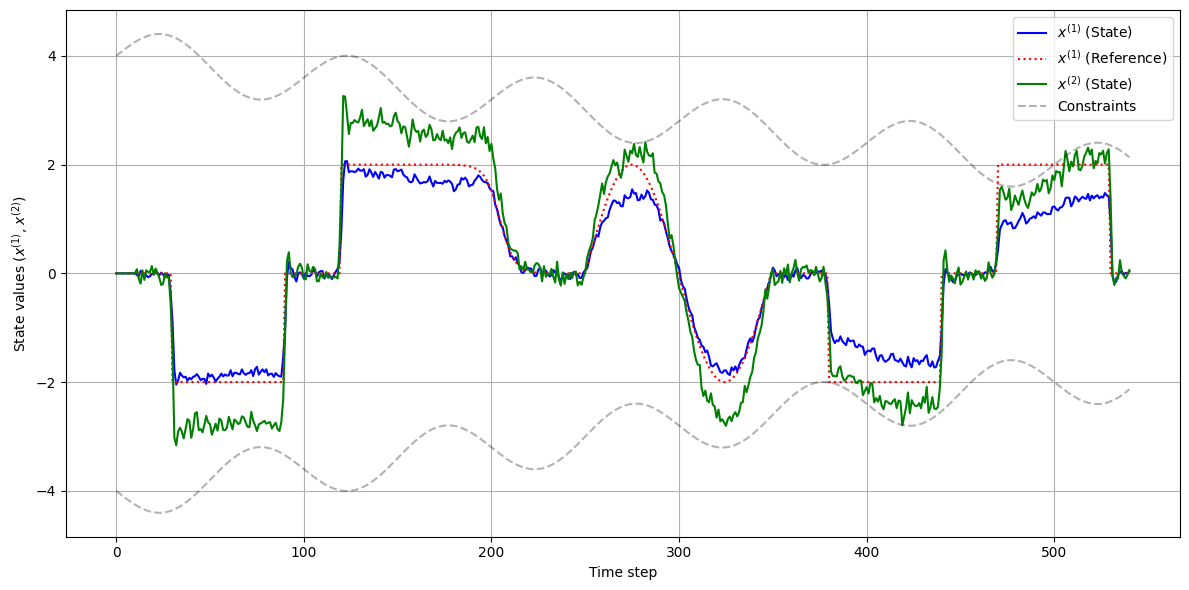

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 1. CSV 파일 경로
# ===============================
file_path = "/home/ftk3187/github/IEMS490/model-based-diffusion_pytorch_tide/results/csv/mpc_diffusion_result_lambda0.1_Nsample_1024.csv"

# ===============================
# 2. 데이터 로드
# ===============================
df = pd.read_csv(file_path)

t = df["time_index"].values
x1 = df["x1_state"].values
x2 = df["x2_state"].values

# ===============================
# 3. Reference 재생성 (run_mpc와 동일)
# ===============================
scaling = 2

Ref_traj_step = np.repeat(np.array([0, -scaling, -scaling, 0, scaling, scaling]), 30)

def sigmoid(x):
    return 1 / (1 + np.exp(-x / 4))

x_tmp = np.linspace(0, 50, 50)
Ref_traj_sigmoid = -sigmoid(x_tmp - 25) * scaling + scaling

x_sin = np.linspace(0, 2 * np.pi, 100)
Ref_traj_sin = scaling * np.sin(x_sin)

Ref_traj = np.concatenate((
    Ref_traj_step,
    Ref_traj_sigmoid,
    np.zeros(20),
    Ref_traj_sin,
    Ref_traj_step,
    np.zeros(20)
))

# 길이 맞춤
Ref_traj = Ref_traj[:len(t)]

# ===============================
# 4. Constraint 재생성
# ===============================
C_up = 4 + 0.5 * np.sin(2 * np.pi * t / 100) - 0.004 * t
C_low = -C_up

# ===============================
# 5. Plot
# ===============================
plt.figure(figsize=(12,6))

# x1 state (blue)
plt.plot(t, x1, color='blue', label=r"$x^{(1)}$ (State)")

# reference (red dotted)
plt.plot(t, Ref_traj, linestyle=':', color='red', label=r"$x^{(1)}$ (Reference)")

# x2 state (green)
plt.plot(t, x2, color='green', label=r"$x^{(2)}$ (State)")

# constraint bounds (black dashed)
plt.plot(t, C_up, 'k--', alpha=0.3, label="Constraints")
plt.plot(t, C_low, 'k--', alpha=0.3)

plt.xlabel("Time step")
plt.ylabel("State values ($x^{(1)}$, $x^{(2)}$)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [4]:
# 정렬
summary_df_sorted = summary_df.sort_values(
    by=["lambda", "Ndiffuse", "Nsample"]
).reset_index(drop=True)

# ---------------------------
# Table 1: Nsample = 2048
# ---------------------------
table_1 = summary_df_sorted[
    summary_df_sorted["Nsample"] == 2048
].copy()

# ---------------------------
# Table 2: Ndiffuse = 50
# ---------------------------
table_2 = summary_df_sorted[
    summary_df_sorted["Ndiffuse"] == 50
].copy()

# Table 2에서 (2048, 50) 제거
table_2 = table_2[
    ~((table_2["Nsample"] == 2048) & (table_2["Ndiffuse"] == 50))
]

# ---------------------------
# Table 3: lambda comparison
# ---------------------------
table_3 = summary_df_sorted[
    (summary_df_sorted["Nsample"] == 2048) &
    (summary_df_sorted["Ndiffuse"] == 50)
].copy()

In [5]:
table_ndiff_1024 = summary_df[
    summary_df["Nsample"] == 2048
].copy()

# Ndiff → lambda 순 정렬
table_ndiff_1024 = table_ndiff_1024.sort_values(
    by=["Ndiffuse", "lambda"]
)

# 같은 (Ndiffuse, lambda) 조합 중 첫 번째 것만 남기기
table_ndiff_1024 = table_ndiff_1024.drop_duplicates(
    subset=["Ndiffuse", "lambda"],
    keep="first"
).reset_index(drop=True)

table_ndiff_1024

def generate_ndiff_lambda_table(df):
    latex = []
    latex.append("\\begin{table}[ht]")
    latex.append("\\centering")
    latex.append("\\begin{tabular}{cccccc}")
    latex.append("\\hline")
    latex.append("$N_{diff}$ & $\\lambda$ & Total Time (s) & Step Time (s) & Mean Dist. & Violations \\\\")
    latex.append("\\hline")

    for _, row in df.iterrows():
        latex.append(
            f"{int(row['Ndiffuse'])} & "
            f"{row['lambda']} & "
            f"{row['total_time_sec']:.2f} & "
            f"{row['step_time_sec']:.3f} & "
            f"{row['combined_mean_distance']:.3f} & "
            f"{int(row['total_violation_count'])} \\\\"
        )

    latex.append("\\hline")
    latex.append("\\end{tabular}")
    latex.append("\\caption{Effect of $N_{diff}$ with $N_{sample}=1024$.}")
    latex.append("\\end{table}")

    return "\n".join(latex)


print(generate_ndiff_lambda_table(table_ndiff_1024))

\begin{table}[ht]
\centering
\begin{tabular}{cccccc}
\hline
$N_{diff}$ & $\lambda$ & Total Time (s) & Step Time (s) & Mean Dist. & Violations \\
\hline
10 & 0.1 & 22.83 & 0.043 & 0.491 & 0 \\
10 & 1.0 & 22.98 & 0.043 & 0.461 & 0 \\
10 & 2.0 & 22.87 & 0.043 & 0.471 & 0 \\
50 & 0.1 & 92.08 & 0.174 & 0.252 & 7 \\
50 & 1.0 & 92.37 & 0.174 & 0.225 & 4 \\
50 & 2.0 & 92.08 & 0.174 & 0.252 & 7 \\
100 & 0.1 & 177.62 & 0.335 & 0.223 & 8 \\
100 & 1.0 & 178.47 & 0.337 & 0.205 & 5 \\
100 & 2.0 & 179.05 & 0.338 & 0.218 & 8 \\
\hline
\end{tabular}
\caption{Effect of $N_{diff}$ with $N_{sample}=1024$.}
\end{table}


In [6]:
table_nsample_50 = summary_df[
    summary_df["Ndiffuse"] == 50
].copy()

# 정렬: Nsample → lambda
table_nsample_50 = table_nsample_50.sort_values(
    by=["Nsample", "lambda"]
).reset_index(drop=True)

table_nsample_50

table_nsample_50 = table_nsample_50.drop_duplicates(
    subset=["Nsample", "lambda"],
    keep="first"
).reset_index(drop=True)

def generate_nsample_table(df):
    latex = []
    latex.append("\\begin{table}[ht]")
    latex.append("\\centering")
    latex.append("\\begin{tabular}{cccccc}")
    latex.append("\\hline")
    latex.append("$N_{sample}$ & $\\lambda$ & Total Time (s) & Step Time (s) & Mean Dist. & Violations \\\\")
    latex.append("\\hline")

    for _, row in df.iterrows():
        latex.append(
            f"{int(row['Nsample'])} & "
            f"{row['lambda']} & "
            f"{row['total_time_sec']:.2f} & "
            f"{row['step_time_sec']:.3f} & "
            f"{row['combined_mean_distance']:.3f} & "
            f"{int(row['total_violation_count'])} \\\\"
        )

    latex.append("\\hline")
    latex.append("\\end{tabular}")
    latex.append("\\caption{Effect of $N_{sample}$ with $N_{diff}=50$.}")
    latex.append("\\end{table}")

    return "\n".join(latex)


print(generate_nsample_table(table_nsample_50))

\begin{table}[ht]
\centering
\begin{tabular}{cccccc}
\hline
$N_{sample}$ & $\lambda$ & Total Time (s) & Step Time (s) & Mean Dist. & Violations \\
\hline
1024 & 0.1 & 90.15 & 0.170 & 0.277 & 2 \\
1024 & 1.0 & 93.01 & 0.175 & 0.248 & 3 \\
1024 & 2.0 & 88.07 & 0.166 & 0.267 & 6 \\
2048 & 0.1 & 92.08 & 0.174 & 0.252 & 7 \\
2048 & 1.0 & 92.37 & 0.174 & 0.225 & 4 \\
2048 & 2.0 & 92.08 & 0.174 & 0.252 & 7 \\
4096 & 0.1 & 115.30 & 0.218 & 0.240 & 9 \\
4096 & 1.0 & 115.75 & 0.218 & 0.232 & 11 \\
4096 & 2.0 & 116.28 & 0.219 & 0.242 & 6 \\
\hline
\end{tabular}
\caption{Effect of $N_{sample}$ with $N_{diff}=50$.}
\end{table}


In [7]:
def generate_table_2(df):
    latex = []
    latex.append("\\begin{table}[ht]")
    latex.append("\\centering")
    latex.append("\\begin{tabular}{cccccc}")
    latex.append("\\hline")
    latex.append("$\\lambda$ & $N_{sample}$ & Total Time (s) & Step Time (s) & Mean Dist. & Violations \\\\")
    latex.append("\\hline")

    for _, row in df.iterrows():
        latex.append(
            f"{row['lambda']} & {int(row['Nsample'])} & "
            f"{row['total_time_sec']:.2f} & "
            f"{row['step_time_sec']:.3f} & "
            f"{row['combined_mean_distance']:.3f} & "
            f"{int(row['total_violation_count'])} \\\\"
        )

    latex.append("\\hline")
    latex.append("\\end{tabular}")
    latex.append("\\caption{Effect of $N_{sample}$ with $N_{diff}=50$.}")
    latex.append("\\end{table}")

    return "\n".join(latex)

print(generate_table_2(table_2))

\begin{table}[ht]
\centering
\begin{tabular}{cccccc}
\hline
$\lambda$ & $N_{sample}$ & Total Time (s) & Step Time (s) & Mean Dist. & Violations \\
\hline
0.1 & 1024 & 90.15 & 0.170 & 0.277 & 2 \\
0.1 & 4096 & 115.30 & 0.218 & 0.240 & 9 \\
1.0 & 1024 & 93.01 & 0.175 & 0.248 & 3 \\
1.0 & 4096 & 115.75 & 0.218 & 0.232 & 11 \\
2.0 & 1024 & 88.07 & 0.166 & 0.267 & 6 \\
2.0 & 4096 & 116.28 & 0.219 & 0.242 & 6 \\
\hline
\end{tabular}
\caption{Effect of $N_{sample}$ with $N_{diff}=50$.}
\end{table}


In [8]:
def generate_table_3(df):
    latex = []
    latex.append("\\begin{table}[ht]")
    latex.append("\\centering")
    latex.append("\\begin{tabular}{ccccc}")
    latex.append("\\hline")
    latex.append("$\\lambda$ & Total Time (s) & Step Time (s) & Mean Dist. & Violations \\\\")
    latex.append("\\hline")

    for _, row in df.iterrows():
        latex.append(
            f"{row['lambda']} & "
            f"{row['total_time_sec']:.2f} & "
            f"{row['step_time_sec']:.3f} & "
            f"{row['combined_mean_distance']:.3f} & "
            f"{int(row['total_violation_count'])} \\\\"
        )

    latex.append("\\hline")
    latex.append("\\end{tabular}")
    latex.append("\\caption{Effect of $\\lambda$ with $N_{diff}=50$, $N_{sample}=2048$.}")
    latex.append("\\end{table}")

    return "\n".join(latex)

print(generate_table_3(table_3))

\begin{table}[ht]
\centering
\begin{tabular}{ccccc}
\hline
$\lambda$ & Total Time (s) & Step Time (s) & Mean Dist. & Violations \\
\hline
0.1 & 92.08 & 0.174 & 0.252 & 7 \\
0.1 & 91.85 & 0.173 & 0.266 & 8 \\
1.0 & 92.37 & 0.174 & 0.225 & 4 \\
1.0 & 92.45 & 0.174 & 0.286 & 9 \\
2.0 & 92.08 & 0.174 & 0.252 & 7 \\
2.0 & 92.19 & 0.174 & 0.261 & 6 \\
\hline
\end{tabular}
\caption{Effect of $\lambda$ with $N_{diff}=50$, $N_{sample}=2048$.}
\end{table}


In [9]:
import os
import glob
import pandas as pd
import numpy as np

# ===============================
# 1. 폴더 경로
# ===============================
folder_path = "/home/ftk3187/github/IEMS490/model-based-diffusion_pytorch_tide/results/csv"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
print(f"Found {len(csv_files)} CSV files")

# ===============================
# 2. 데이터 로딩 + constraint 계산
# ===============================
data_dict = {}

for file in csv_files:
    df = pd.read_csv(file)

    t = df["time_index"].values
    x2 = df["x2_state"].values

    # Constraint 재계산
    C_up = 4 + 0.5 * np.sin(2 * np.pi * t / 100) - 0.004 * t
    C_low = -C_up

    data_dict[os.path.basename(file)] = {
        "t": t,
        "x2": x2,
        "C_up": C_up,
        "C_low": C_low
    }

print("Data loaded and constraints computed.")

Found 18 CSV files
Data loaded and constraints computed.


In [10]:
# 두 구간 정의
range_1 = (380, 440)
range_2 = (470, 530)

def compute_combined_mean_distance(t, x2, C_up, C_low, range1, range2):
    
    # 두 구간 마스크 결합
    mask1 = (t >= range1[0]) & (t < range1[1])
    mask2 = (t >= range2[0]) & (t < range2[1])
    mask = mask1 | mask2
    
    x2_seg = x2[mask]
    up_seg = C_up[mask]
    low_seg = C_low[mask]

    # constraint 내부 거리 계산
    dist_upper = up_seg - x2_seg
    dist_lower = x2_seg - low_seg
    dist = np.minimum(dist_upper, dist_lower)

    # constraint 내부만 사용
    dist = dist[dist >= 0]

    if len(dist) == 0:
        return 0
    
    return np.mean(dist)


print("=== Combined Mean Distance (380–440 & 470–530) ===\n")

for name, data in data_dict.items():
    
    mean_dist = compute_combined_mean_distance(
        data["t"],
        data["x2"],
        data["C_up"],
        data["C_low"],
        range_1,
        range_2
    )

    print(f"{name}")
    print(f"  Combined Mean Distance: {mean_dist:.4f}")
    print("-" * 50)

=== Combined Mean Distance (380–440 & 470–530) ===

mpc_diffusion_result_lambda2_Nsample_2048.csv
  Combined Mean Distance: 0.2522
--------------------------------------------------
mpc_diffusion_result_lambda1_Nsample_1024.csv
  Combined Mean Distance: 0.2478
--------------------------------------------------
mpc_diffusion_result_lambda0.1_Nsample_2048.csv
  Combined Mean Distance: 0.2522
--------------------------------------------------
mpc_diffusion_result_lambda2_Ndiffuse_50.csv
  Combined Mean Distance: 0.2607
--------------------------------------------------
mpc_diffusion_result_lambda2_Nsample_4096.csv
  Combined Mean Distance: 0.2424
--------------------------------------------------
mpc_diffusion_result_lambda2_Ndiffuse_10.csv
  Combined Mean Distance: 0.4706
--------------------------------------------------
mpc_diffusion_result_lambda0.1_Ndiffuse_50.csv
  Combined Mean Distance: 0.2656
--------------------------------------------------
mpc_diffusion_result_lambda1_Ndiffuse

In [11]:
print("=== Total Constraint Violations ===\n")

for name, data in data_dict.items():
    violation = (data["x2"] > data["C_up"]) | (data["x2"] < data["C_low"])
    total_violation_count = np.sum(violation)

    print(f"{name}")
    print(f"  Total Violations: {total_violation_count}")
    print("-" * 50)

=== Total Constraint Violations ===

mpc_diffusion_result_lambda2_Nsample_2048.csv
  Total Violations: 7
--------------------------------------------------
mpc_diffusion_result_lambda1_Nsample_1024.csv
  Total Violations: 3
--------------------------------------------------
mpc_diffusion_result_lambda0.1_Nsample_2048.csv
  Total Violations: 7
--------------------------------------------------
mpc_diffusion_result_lambda2_Ndiffuse_50.csv
  Total Violations: 6
--------------------------------------------------
mpc_diffusion_result_lambda2_Nsample_4096.csv
  Total Violations: 6
--------------------------------------------------
mpc_diffusion_result_lambda2_Ndiffuse_10.csv
  Total Violations: 0
--------------------------------------------------
mpc_diffusion_result_lambda0.1_Ndiffuse_50.csv
  Total Violations: 8
--------------------------------------------------
mpc_diffusion_result_lambda1_Ndiffuse_50.csv
  Total Violations: 4
--------------------------------------------------
mpc_diffusi

In [12]:
print("=== Computation Time per Case ===\n")

for file in csv_files:
    df = pd.read_csv(file)
    
    name = os.path.basename(file)
    
    if "elapsed_total_sec" in df.columns:
        total_time = df["elapsed_total_sec"].iloc[0]
        step_time = df["elapsed_per_step_sec"].iloc[0]
        
        print(f"{name}")
        print(f"  Total Time (sec): {total_time:.4f}")
        print(f"  Avg Time per Step (sec): {step_time:.6f}")
        print("-" * 50)
    else:
        print(f"{name} -> No time columns found")
        print("-" * 50)

=== Computation Time per Case ===

mpc_diffusion_result_lambda2_Nsample_2048.csv
  Total Time (sec): 92.0760
  Avg Time per Step (sec): 0.173728
--------------------------------------------------
mpc_diffusion_result_lambda1_Nsample_1024.csv
  Total Time (sec): 93.0073
  Avg Time per Step (sec): 0.175486
--------------------------------------------------
mpc_diffusion_result_lambda0.1_Nsample_2048.csv
  Total Time (sec): 92.0847
  Avg Time per Step (sec): 0.173745
--------------------------------------------------
mpc_diffusion_result_lambda2_Ndiffuse_50.csv
  Total Time (sec): 92.1891
  Avg Time per Step (sec): 0.173942
--------------------------------------------------
mpc_diffusion_result_lambda2_Nsample_4096.csv
  Total Time (sec): 116.2806
  Avg Time per Step (sec): 0.219397
--------------------------------------------------
mpc_diffusion_result_lambda2_Ndiffuse_10.csv
  Total Time (sec): 22.8670
  Avg Time per Step (sec): 0.043145
-------------------------------------------------